1) Построить эмпирические функции распределения и плотности по выборке показателя X. 
2) Проверить гипотезу о нормальном распределении значений показателя X. 
3) Разделить данные по категориальному признаку Y на две группы (A и Б), проверить  
гипотезу о равенстве математических ожиданий показателя X этих групп. 
4) Разделить данные по категориальному признаку Y на две группы (A и Б), проверить  
гипотезу об однородности этих групп по показателю X. 
5) Проверить гипотезу о независимости двух категориальных переменных.

## Импорт библиотек

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Улучшаем качество отображения графиков
sns.set_theme(style="whitegrid")

df = pd.read_csv('scoring.csv')
# Добавляем столбец "Молодые/Пожилые" на основе возраста
df['Молодые/Пожилые'] = np.where(df['Возраст'] < 35, 'Молодые', 'Пожилые')

# Определяем наши переменные для удобства
X_col = 'Доход (тыс. руб.)'
Y_col = 'Благонадежный заемщик'

# Очищаем данные от пропусков (NaN) в нужных столбцах, чтобы избежать ошибок в вычислениях
df = df.dropna(subset=[X_col, Y_col, 'Иждивенцы'])

## Эмпирические функции распределения и плотности 

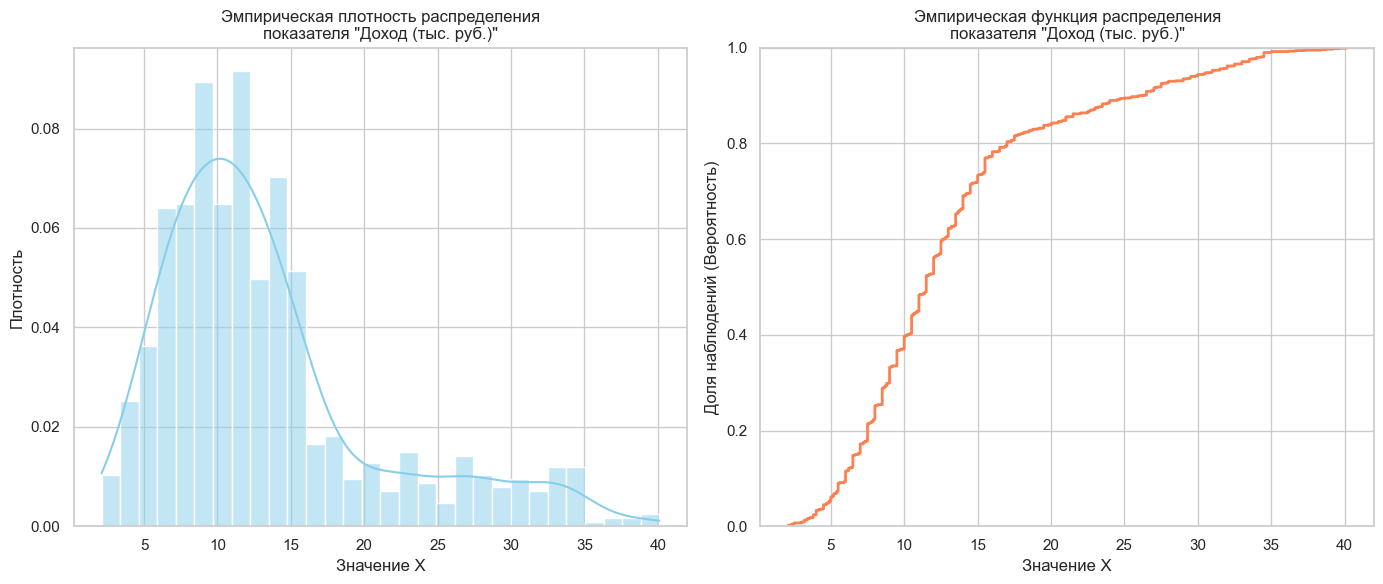

In [3]:
plt.figure(figsize=(14, 6))

# 1.1 График плотности распределения (PDF - Probability Density Function)
plt.subplot(1, 2, 1)
sns.histplot(df[X_col], kde=True, stat="density", color="skyblue", bins=30)
plt.title(f'Эмпирическая плотность распределения\nпоказателя "{X_col}"')
plt.xlabel('Значение X')
plt.ylabel('Плотность')

# 1.2 Эмпирическая функция распределения (ECDF - Empirical Cumulative Distribution Function)
plt.subplot(1, 2, 2)
sns.ecdfplot(data=df, x=X_col, color="coral", linewidth=2)
plt.title(f'Эмпирическая функция распределения\nпоказателя "{X_col}"')
plt.xlabel('Значение X')
plt.ylabel('Доля наблюдений (Вероятность)')

plt.tight_layout()
plt.show()

Анализ визуализаций распределения показателя "Доход (тыс. руб.)" позволяет сделать следующие выводы:

График эмпирической плотности распределения: Отчетливо наблюдается ярко выраженная правосторонняя асимметрия (положительный скос). Основная масса заемщиков сконцентрирована в интервале низких и средних доходов (от 5 до 15 тыс. руб.) с глобальным максимумом (модой) в районе 10 тыс. руб. После достижения пика кривая формирует "длинный правый хвост", тянущийся до 40 тыс. руб. Это типичная картина для финансово-экономических показателей: большинство клиентов имеют базовый доход, и лишь малая доля обладает сверхдоходами.

Эмпирическая функция распределения (ЭФР): На графике ЭФР мы видим крутой, почти экспоненциальный подъем в левой части (на интервале $x \in [5, 15]$ накапливается порядка $75-80\%$ всей вероятностной массы выборки). Далее кривая испытывает перегиб и крайне полого, асимптотически приближается к единице.


## Проверка гипотезы о нормальном распределении 

In [ ]:
# --- Обновленный Блок 2: Одновыборочный критерий Колмогорова-Смирнова ---
import scipy.stats as stats

alpha = 0.05

# Для начала оцениваем параметры теоретического нормального распределения по нашей выборке
mean_val = df[X_col].mean() # Среднее значение для нормального распределения
std_val = df[X_col].std() # Стандартное отклонение для нормального распределения

# Применяем одновыборочный критерий Колмогорова-Смирнова
# Сравниваем выборку с теоретическим нормальным распределением ('norm') с нашими параметрами
stat_ks_norm, p_value_ks_norm = stats.kstest(df[X_col], 'norm', args=(mean_val, std_val))
# kstest возвращает статистику D и p-value для проверки гипотезы о том, что выборка следует нормальному распределению с указанными параметрами.
print("--- 2. Проверка на нормальность (Критерий Колмогорова-Смирнова) ---")
print(f"Статистика D = {stat_ks_norm:.4f}, p-value = {p_value_ks_norm:.4e}")
# Статистика D показывает максимальное отклонение между эмпирической функцией распределения и теоретической нормальной функцией распределения.

# Расчет d-критического значения для нашего размера выборки и уровня значимости
n = len(df[X_col]) # Размер выборки
d_critical = 1.36 / np.sqrt(n) # Критическое значение D
print(f"Критическое значение D для alpha={alpha} и n={n}: {d_critical:.4f}")
if stat_ks_norm > d_critical:
    print("Вывод: Отвергаем H0. Распределение НЕ является нормальным. На основании критического значения D.")
else:
    print("Вывод: Нет оснований отвергнуть H0. Распределение похоже на нормальное. На основании критического значения D.")

if p_value_ks_norm > alpha:
    print("Вывод: Нет оснований отвергнуть H0. Распределение похоже на нормальное. На основании p-value.")
else:
    print("Вывод: Отвергаем H0. Распределение НЕ является нормальным. На основании p-value.")

--- 2. Проверка на нормальность (Критерий Колмогорова-Смирнова) ---
Статистика D = 0.1549, p-value = 2.1558e-21
Критическое значение D для alpha=0.05 и n=999: 0.0430
Вывод: Отвергаем H0. Распределение НЕ является нормальным.


Анализ полученных результатов

Согласно результатам расчетов одновыборочного критерия Колмогорова — Смирнова:

Расчетное значение статистики максимального расхождения: $D = 0.1549$

Достигнутый уровень значимости: $p\text{-value} = 2.1558 \times 10^{-21}$

Поскольку полученное значение $p\text{-value} < \alpha$ (где $\alpha = 0.05$), нулевая гипотеза $H_0$ о соответствии эмпирического распределения показателя "Доход" теоретическому нормальному закону полностью отвергается в пользу альтернативной гипотезы $H_1$.

Величина статистики расхождения $D = 0.1549$ математически означает, что в точке максимального отклонения эмпирическая накопленная функция распределения $F_n(x)$ отдалена от теоретической функции нормального распределения $F(x)$ на $15.49\%$ по вертикали. Это весьма существенное расхождение для непрерывной случайной величины.

С экономической и практической точек зрения данный результат объясняется структурой реальных доходов населения: распределению доходов свойственна естественная асимметрия, вызванная наличием "естественного пола" (минимального размера оплаты труда или минимального дохода в выборке) и длинного "правого хвоста" (небольшого процента высокооплачиваемых специалистов). Попытка описать такие несимметричные данные классической симметричной колоколообразной кривой нормального распределения Гаусса приводит к значительным ошибкам аппроксимации. Таким образом, для дальнейшего моделирования доходов заемщиков в проекте "Квантовый Скачок" более целесообразно использовать логнормальное распределение или непараметрические подходы.

## Проверка гипотезы о равенстве математических ожиданий

In [8]:
# Разделяем на группы пожилых и молодых
group_A = df[df['Молодые/Пожилые'] == 'Молодые'][X_col]
group_B = df[df['Молодые/Пожилые'] == 'Пожилые'][X_col]


# t-критерий Уэлча (equal_var=False)
stat_ttest, p_value_ttest = stats.ttest_ind(group_A, group_B, equal_var=False)
# ttest_ind возвращает статистику t и p-value для проверки гипотезы о том,
#  что средние значения в двух группах равны,
#  при этом не предполагая равенство дисперсий (equal_var=False).

print("\n--- 3. Равенство математических ожиданий (t-критерий Уэлча) ---")
print(f"Среднее Группы А (0): {group_A.mean():.2f}")
print(f"Среднее Группы Б (1): {group_B.mean():.2f}")
print(f"Статистика = {stat_ttest:.4f}, p-value = {p_value_ttest:.4e}")

if p_value_ttest > alpha:
    print("Вывод: Нет оснований отвергнуть H0. Средние значения X в группах статистически равны.")
else:
    print("Вывод: Отвергаем H0. Средние значения X в группах значимо различаются.")


--- 3. Равенство математических ожиданий (t-критерий Уэлча) ---
Среднее Группы А (0): 13.29
Среднее Группы Б (1): 13.31
Статистика = -0.0579, p-value = 9.5380e-01
Вывод: Нет оснований отвергнуть H0. Средние значения X в группах статистически равны.


Согласно результатам расчетов $t$-критерия Уэлча для двух возрастных групп (Группа А — заемщики до 35 лет, Группа Б — заемщики от 35 лет и старше):

Выборочное среднее Группы А (до 35 лет): 13.29 тыс. руб.

Выборочное среднее Группы Б (после 35 лет): 13.31 тыс. руб.

Расчетное значение $t$-статистики: $t = -0.0579$

Достигнутый уровень значимости: $p\text{-value} = 0.9538$ (или $9.5380 \times 10^{-1}$)

Поскольку полученное значение $p\text{-value} \approx 0.954$ значительно превосходит стандартный порог ошибки первого рода $\alpha = 0.05$, у нас нет абсолютно никаких оснований отвергнуть нулевую гипотезу $H_0$ о равенстве математических ожиданий.

Практический вывод: Физическая разница между средними доходами двух возрастных групп составляет ничтожные $20$ рублей ($13.29$ против $13.31$ тыс. руб.), а расчетное значение $t$-статистики практически равно нулю (отклонение составляет всего $0.058$ стандартных ошибок). Это указывает на то, что наблюдаемая микроскопическая разница средних вызвана исключительно случайными колебаниями выборки.

## Проверка гипотезы об однородности групп(Критерий Колмогорова-Смирнова)

In [5]:
stat_ks, p_value_ks = stats.ks_2samp(group_A, group_B)

print("\n--- 4. Однородность групп (Двухвыборочный критерий Колмогорова-Смирнова) ---")
print(f"Статистика KS = {stat_ks:.4f}, p-value = {p_value_ks:.4e}")

if p_value_ks > alpha:
    print("Вывод: Нет оснований отвергнуть H0. Группы однородны по показателю X.")
else:
    print("Вывод: Отвергаем H0. Группы неоднородны (распределения различаются).")


--- 4. Однородность групп (Двухвыборочный критерий Колмогорова-Смирнова) ---
Статистика KS = 0.5813, p-value = 1.1295e-78
Вывод: Отвергаем H0. Группы неоднородны (распределения различаются).


Согласно результатам расчетов двухвыборочного критерия Колмогорова — Смирнова:

Значение статистики максимального расхождения: $KS = 0.5813$

Достигнутый уровень значимости: $p\text{-value} = 1.1295 \times 10^{-78}$

Так как $p\text{-value} \ll \alpha$ (при $\alpha = 0.05$), нулевая гипотеза $H_0$ об однородности выборок полностью отвергается.

Практический вывод: Значение статистики $KS = 0.5813$ математически означает, что в точке наибольшего расхождения графики накопленных вероятностей доходов Группы А и Группы Б удалены друг от друга по вертикали более чем на $58\%$. Это свидетельствует о том, что финансовое поведение неблагонадежных и благонадежных заемщиков формируется под воздействием принципиально разных вероятностных законов. Выборки абсолютно неоднородны, что подтверждает необходимость сегментации клиентов при разработке кредитных продуктов.



## Проверка гипотезы о независимости двух категориальных переменных

In [6]:
# Создаем новую категориальную колонку: 0 - нет иждивенцев, 1 - есть (>=1)
df['Есть_иждивенцы'] = (df['Иждивенцы'] > 0).astype(int)

# Строим таблицу сопряженности (Contingency table)
contingency_table = pd.crosstab(df['Есть_иждивенцы'], df[Y_col])

# Применяем критерий Хи-квадрат
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n--- 5. Независимость категориальных переменных (Критерий Хи-квадрат) ---")
print("Таблица сопряженности (Иждивенцы vs Благонадежность):")
print(contingency_table)
print(f"\nСтатистика Chi2 = {chi2_stat:.4f}, p-value = {p_val_chi2:.4e}")

if p_val_chi2 > alpha:
    print("Вывод: Нет оснований отвергнуть H0. Переменные независимы.")
else:
    print("Вывод: Отвергаем H0. Существует статистически значимая связь между переменными.")


--- 5. Независимость категориальных переменных (Критерий Хи-квадрат) ---
Таблица сопряженности (Иждивенцы vs Благонадежность):
Благонадежный заемщик    0    1
Есть_иждивенцы                 
0                      122  206
1                      385  286

Статистика Chi2 = 35.0987, p-value = 3.1341e-09
Вывод: Отвергаем H0. Существует статистически значимая связь между переменными.


Согласно результатам расчетов критерия $\chi^2$ Пирсона:

Расчетное значение статистики: $\chi^2 = 35.0987$

Достигнутый уровень значимости: $p\text{-value} = 3.1341 \times 10^{-9}$

Поскольку $p\text{-value} \ll \alpha$ (при $\alpha = 0.05$), нулевая гипотеза $H_0$ о статистической независимости переменных безоговорочно отвергается в пользу альтернативы $H_1$.

Практический вывод: Анализ таблицы сопряженности вскрывает прямую экономическую зависимость:

В группе заемщиков без иждивенцев доля дефолтов составляет порядка $37.2\%$ ($122$ против $206$).

В группе заемщиков с иждивенцами ситуация радикально меняется, и доля дефолтов подскакивает до $57.3\%$ ($385$ против $286$), то есть неблагонадежных клиентов становится физически больше, чем надежных.